В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises. Solution


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

Один розробник використав комп'ютерний зір щоб робити банановий сендвіч. Модель визначає як розрізати банан та ідеально розташувати шматочки на тості :)
- В охороних системах
- Для створення роботів
- Для інспекції промислових товарів

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

Пощупала як відбувається трансформація мого зображення між різними шарами. А саме як відбуваються розрахунки для згорткового шару. Як працює функції активації ReLU і Softmax.
А ще дізналась що за 20 хвилин можна ознайомитись з новим методом побудови нейроних мереж

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [1]:
# Імпортуємо PyTorch
import torch
from torch import nn

# Імпортуємо torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Імпортуємо matplotlib для візуалізації
import matplotlib.pyplot as plt

# Перевіряємо версії
# Примітка: ваша версія PyTorch не повинна бути нижчою за 1.10.0, а версія torchvision не повинна бути нижчою за 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.8.0+cu126
torchvision version: 0.23.0+cu126


In [2]:
# Налаштування навчальних даних
train_data = torchvision.datasets.MNIST(
    root="data", # куди завантажити дані?
    train=True, # отримати навчальні дані
    download=True, # завантажити дані, якщо їх немає на диску
    transform=ToTensor(), # зображення приходять у форматі PIL, ми хочемо перетворити їх на тензори Torch
    target_transform=None # ви також можете перетворити мітки
)

# Налаштування тестових даних
test_data = torchvision.datasets.MNIST(
    root="data",
    train=False, # отримати тестові дані
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 121kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

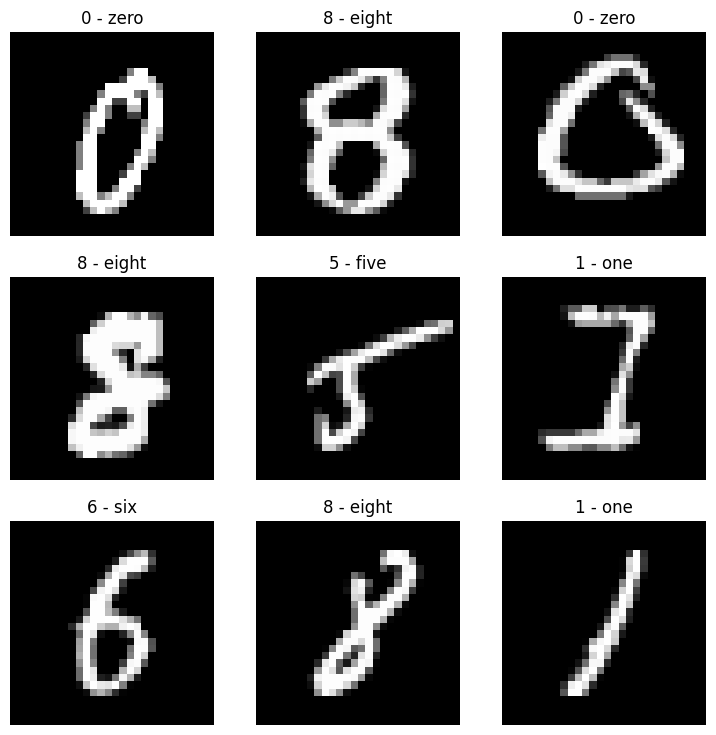

In [3]:
import matplotlib.pyplot as plt
# Відобразити більше зображень
class_names = train_data.classes
torch.manual_seed(43)
fig = plt.figure(figsize=(9, 9))
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [4]:
from torch.utils.data import DataLoader

# Налаштування гіперпараметра розміру партії
BATCH_SIZE = 32

# Перетворення наборів даних на ітерабельні (партії)
train_dataloader = DataLoader(train_data, # набір даних, який потрібно перетворити на ітерабельний
    batch_size=BATCH_SIZE, # скільки зразків на партію?
    shuffle=True # перемішувати дані на кожній епосі?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # не обов'язково перемішувати тестові дані
)

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [5]:
# Налаштування коду, незалежного від пристрою
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
# Створення згорткової нейронної мережі
class FashionMNISTModelV2(nn.Module):
    """
    Архітектура моделі, що копіює TinyVGG з:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # якого розміру квадрат, що проходить по зображенню?
                      stride=1, # за замовчуванням
                      padding=1),# варіанти = "valid" (без заповнення) або "same" (вихід має таку ж форму, як вхід) або int для конкретного числа
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # значення кроку за замовчуванням таке ж, як і розмір ядра
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Звідки взялася ця форма in_features?
            # Це тому, що кожен шар нашої мережі стискає та змінює форму наших вхідних даних.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [7]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Відправка даних на GPU
        X, y = X.to(device), y.to(device)

        # 1. Прямий прохід
        y_pred = model(X)

        # 2. Обчислення втрат
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Перехід від логітів до предсказаних міток

        # 3. Обнулення градієнтів оптимізатора
        optimizer.zero_grad()

        # 4. Зворотний прохід втрат
        loss.backward()

        # 5. Крок оптимізатора
        optimizer.step()

    # Обчислення втрат і точності за епоху та виведення результатів
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # перевести модель в режим оцінки
    # Увімкнути контекстний менеджер для інференції
    with torch.inference_mode():
        for X, y in data_loader:
            # Відправка даних на GPU
            X, y = X.to(device), y.to(device)

            # 1. Прямий прохід
            test_pred = model(X)

            # 2. Обчислення втрат і точності
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Перехід від логітів до предсказаних міток
            )

        # Коригування метрик і виведення результатів
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [8]:
# Налаштування функції втрат та оптимізатора
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [10]:
torch.manual_seed(42)
from tqdm.auto import tqdm
import helper_functions
from helper_functions import accuracy_fn, print_train_time

# Вимірювання часу
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Навчання та тестування моделі
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.33363 | Train accuracy: 88.80%
Test loss: 0.07404 | Test accuracy: 97.66%

Епоха: 1
---------
Train loss: 0.08163 | Train accuracy: 97.43%
Test loss: 0.06354 | Test accuracy: 97.93%

Епоха: 2
---------
Train loss: 0.06400 | Train accuracy: 98.00%
Test loss: 0.05435 | Test accuracy: 98.12%

Епоха: 3
---------
Train loss: 0.05468 | Train accuracy: 98.25%
Test loss: 0.06056 | Test accuracy: 98.05%

Епоха: 4
---------
Train loss: 0.04872 | Train accuracy: 98.47%
Test loss: 0.04144 | Test accuracy: 98.45%


Train time on cuda: 58.455 seconds


In [11]:
device = "cpu"

In [12]:
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.04437 | Train accuracy: 98.57%
Test loss: 0.04793 | Test accuracy: 98.42%

Епоха: 1
---------
Train loss: 0.04048 | Train accuracy: 98.71%
Test loss: 0.04483 | Test accuracy: 98.50%

Епоха: 2
---------
Train loss: 0.03798 | Train accuracy: 98.81%
Test loss: 0.04193 | Test accuracy: 98.57%

Епоха: 3
---------
Train loss: 0.03589 | Train accuracy: 98.83%
Test loss: 0.04096 | Test accuracy: 98.65%

Епоха: 4
---------
Train loss: 0.03301 | Train accuracy: 98.91%
Test loss: 0.03734 | Test accuracy: 98.80%


Train time on cpu: 337.689 seconds


Різниця в часі прям відчутна.

## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [13]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Повертає словник, що містить результати прогнозування моделі на data_loader.

    Args:
        model (torch.nn.Module): Модель PyTorch, здатна робити прогнози на data_loader.
        data_loader (torch.utils.data.DataLoader): Цільовий набір даних для прогнозування.
        loss_fn (torch.nn.Module): Функція втрат моделі.
        accuracy_fn: Функція точності для порівняння прогнозів моделі з істинними мітками.

    Returns:
        (dict): Результати прогнозування моделі на data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Зробіть прогнози за допомогою моделі
            y_pred = model(X)

            # Накопичте значення втрат і точності за кожну партію
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # Для точності потрібні мітки прогнозів (логіти -> пред_ймовірності -> пред_мітки)

        # Масштабуйте втрати та точність, щоб знайти середні втрати/точність за партію
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # працює лише коли модель була створена з класом
            "model_loss": loss.item(),
            "model_acc": acc}

In [14]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.03733757883310318,
 'model_acc': 98.80191693290735}

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [15]:
# Імпортуємо tqdm для індикатора прогресу
from tqdm.auto import tqdm

# 1. Зробіть прогнози з навченою моделлю
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Зроблення прогнозів"):
    # Відправте дані та цілі на цільовий пристрій
    X, y = X.to(device), y.to(device)
    # Виконайте прямий прохід
    y_logit = model_2(X)
    # Перетворіть прогнози з логітів -> ймовірності прогнозів -> мітки прогнозів
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # зауваження: виконуйте softmax на вимірі "логітів", а не "пакету" (в даному випадку у нас розмір пакету 32, тому можна виконати на dim=1)
    # Помістіть прогнози на CPU для оцінки
    y_preds.append(y_pred.cpu())
# Об'єднайте список прогнозів в тензор
y_pred_tensor = torch.cat(y_preds)

Зроблення прогнозів:   0%|          | 0/313 [00:00<?, ?it/s]

In [16]:
# Перевірте, чи існує torchmetrics, якщо ні, встановіть його
try:
    import torchmetrics, mlxtend
    print(f"mlxtend версія: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "версія mlxtend повинна бути 0.19.0 або вище"
except:
    !pip install -q torchmetrics -U mlxtend # <- Примітка: Якщо ви використовуєте Google Colab, це може вимагати перезапуску середовища виконання
    import torchmetrics, mlxtend
    print(f"mlxtend версія: {mlxtend.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.7 MB/s eta 0:00:00
mlxtend версія: 0.23.4


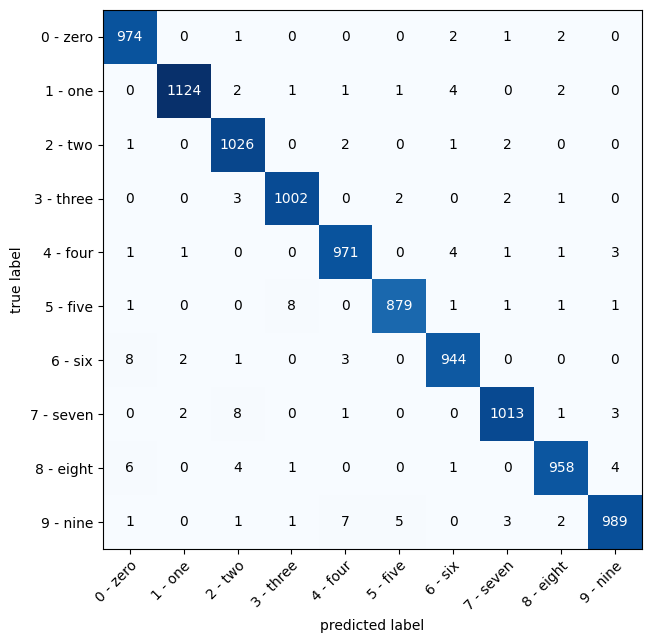

In [17]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Налаштування екземпляра матриці плутанини та порівняння прогнозів з цілями
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Побудова матриці плутанини
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib любить працювати з NumPy
    class_names=class_names, # перетворення міток рядків і стовпців на назви класів
    figsize=(10, 7)
);

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [18]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Підготовка зразка
            sample = torch.unsqueeze(sample, dim=0).to(device) # Додати додатковий вимір і надіслати зразок на пристрій

            # Прямий прохід (модель видає сирий логіт)
            pred_logit = model(sample)

            # Отримати ймовірність прогнозу (логіт -> ймовірність прогнозу)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # зауваження: виконати softmax на вимірі "логітів", а не "пакетів" (в цьому випадку у нас розмір пакета 1, тому можна виконати на dim=0)

            # Отримати pred_prob з GPU для подальших обчислень
            pred_probs.append(pred_prob.cpu())

    # Об'єднати pred_probs, щоб перетворити список в тензор
    return torch.stack(pred_probs)


In [19]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=1000):
    test_samples.append(sample)
    test_labels.append(label)

pred_probs= make_predictions(model=model_2,
                             data=test_samples)
pred_classes = pred_probs.argmax(dim=1)

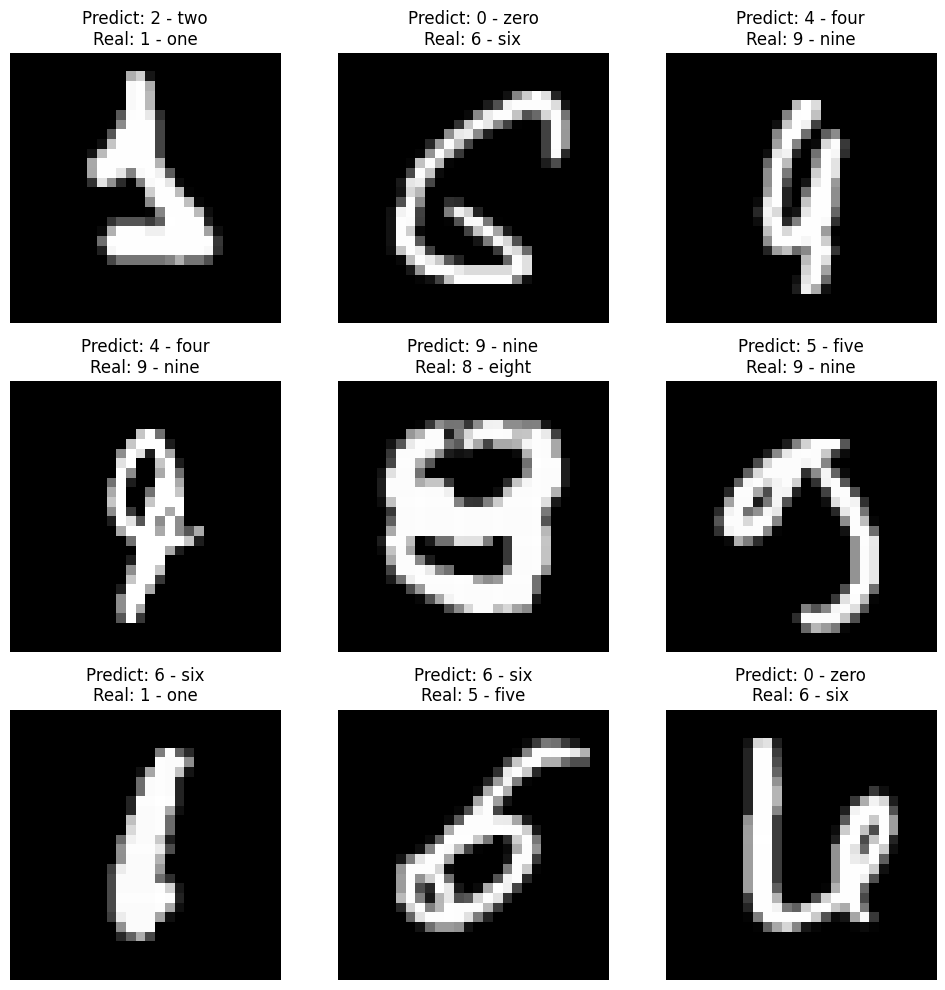

In [22]:
plt.figure(figsize=(10, 10))

wrong_indices = [i for i in range(len(test_labels)) if pred_classes[i] != test_labels[i]]

n_show = min(9, len(wrong_indices))
nrows, ncols = 3, 3

for idx, i in enumerate(wrong_indices[:n_show]):
    plt.subplot(nrows, ncols, idx + 1)
    plt.imshow(test_samples[i].squeeze(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    true_label = class_names[test_labels[i]]
    plt.title(f"Predict: {pred_label}\nReal: {true_label}")
    plt.axis(False)

plt.tight_layout()
plt.show()

Насправді модель максимально точно передбачає, не так було легко назбирати ці помилкові кейси і це ж можна побачити на матриці плутанини. Деякі ситуації дійсно дуже незрозумілі зображення, а в деяких ситуаціях дійсно помилка моделі. Можливо можна щось ще покращувати, але питання чи воно того варте.

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [23]:
torch.manual_seed(42)

images = torch.randn(size=(1, 3, 64, 64))
test_image = images[0]
print(f"Піксельні значення одного зображення:\n{test_image}")

Піксельні значення одного зображення:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354, -0.0780],
       

In [24]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=5,
                       stride=1,
                       padding=0)

conv_layer(test_image).shape

torch.Size([10, 60, 60])

Якщо kernel_size збільшується, то зменшується розмір зображення на виході, тому що ми не задали падінги )
Нарешті зрозуміла, звідки береться 10 каналів з трьох